In [136]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.timeseries import LombScargle
from scipy.optimize import minimize_scalar, brentq
import toolz as tz

In [137]:
df1 = pd.read_csv("star1.csv", sep=r"\s+", header=None)
df2 = pd.read_csv("star2.csv", sep=r"\s+", header=None)
df3 = pd.read_csv("star3.csv", sep=r"\s+", header=None)
df4 = pd.read_csv("star4.csv", sep=r"\s+", header=None)
df5 = pd.read_csv("star5.csv", sep=r"\s+", header=None)

In [138]:
tiempo1 = df1[0] 
tiempo2 = df2[0] 
tiempo3 = df3[0] 
tiempo4 = df4[0] 
tiempo5 = df5[0] 

magnitud1 = df1[1]
magnitud2 = df2[1]
magnitud3 = df3[1]
magnitud4 = df4[1]
magnitud5 = df5[1]

In [139]:
estrellas = [{"t": tiempo1, "mag": magnitud1},{"t": tiempo2, "mag": magnitud2},
    {"t": tiempo3, "mag": magnitud3},{"t": tiempo4, "mag": magnitud4},{"t": tiempo5, "mag": magnitud5},]

In [140]:
def limpiar(t, mag):
    mask = (np.isfinite(t) & np.isfinite(mag))
    t = np.array(t)[mask]
    mag = np.array(mag)[mask]
    idx = np.argsort(t)
    return t[idx], mag[idx]

In [141]:
def buscar_periodo(t, mag, pmin=100, pmax=1000):
    """Retorna freq, power, P — como siempre."""
    freq, power = LombScargle(t, mag).autopower(
        minimum_frequency=1/pmax,
        maximum_frequency=1/pmin,
        samples_per_peak=20)
    P = float(1/freq[np.argmax(power)])
    return freq, power, P

def get_periodo(t, mag, pmin=100, pmax=1000):
    """Retorna solo el período como float — para usar en el pipeline."""
    _, _, P = buscar_periodo(t, mag, pmin, pmax)
    return P

In [142]:
def calcular_fase(t,mag,P):
    t0 = t[np.argmin(mag)]
    return ((t-t0)/P)%1

In [143]:
def refinar_periodo(t,mag,P0,frac=0.1,N=300):
    P0 = float(P0) 
    periodos = np.linspace(P0*(1-frac),P0*(1+frac),N)
    dispersion=[]
    for P in periodos:
        fase=((t-t.min())/P)%1
        bins=np.linspace(0,1,30)
        sig=[]
        for i in range(len(bins)-1):
            m=((fase>=bins[i]) & (fase<bins[i+1]))
            if np.sum(m)>5:
                sig.append(np.std(mag[m]))
        dispersion.append(np.mean(sig))
    return float(periodos[np.argmin(dispersion)])

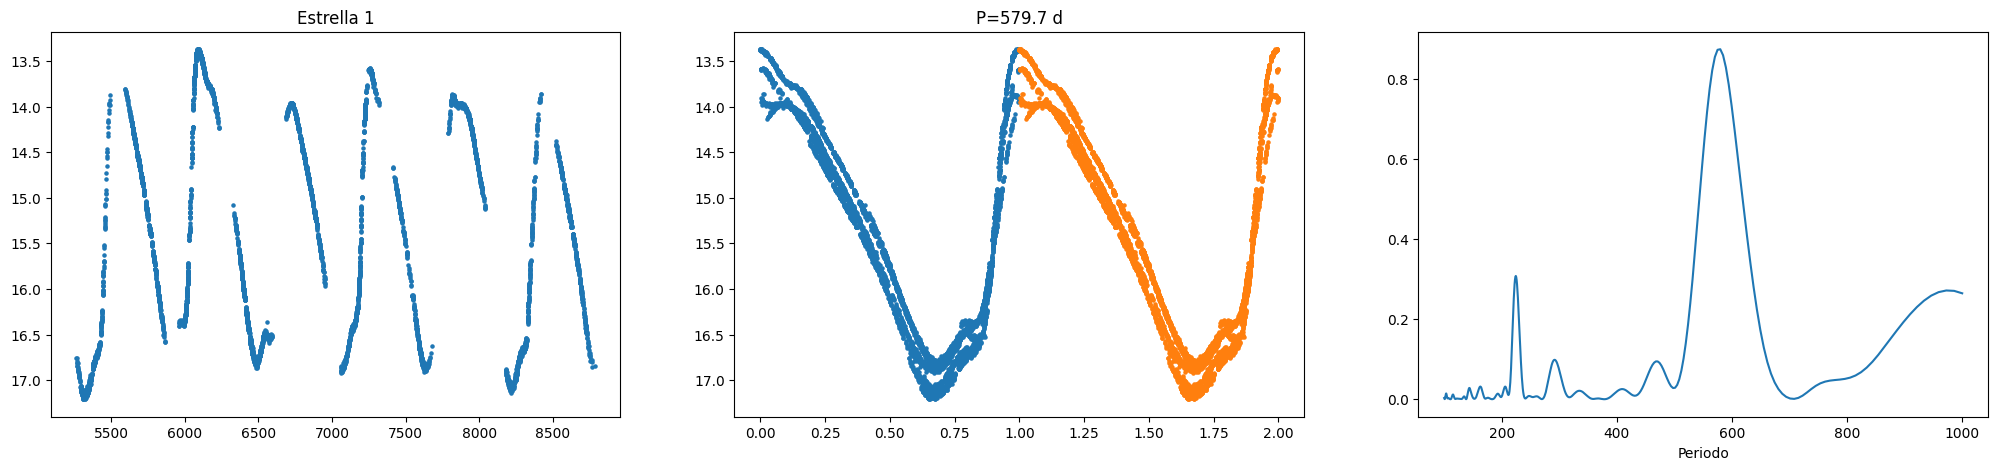

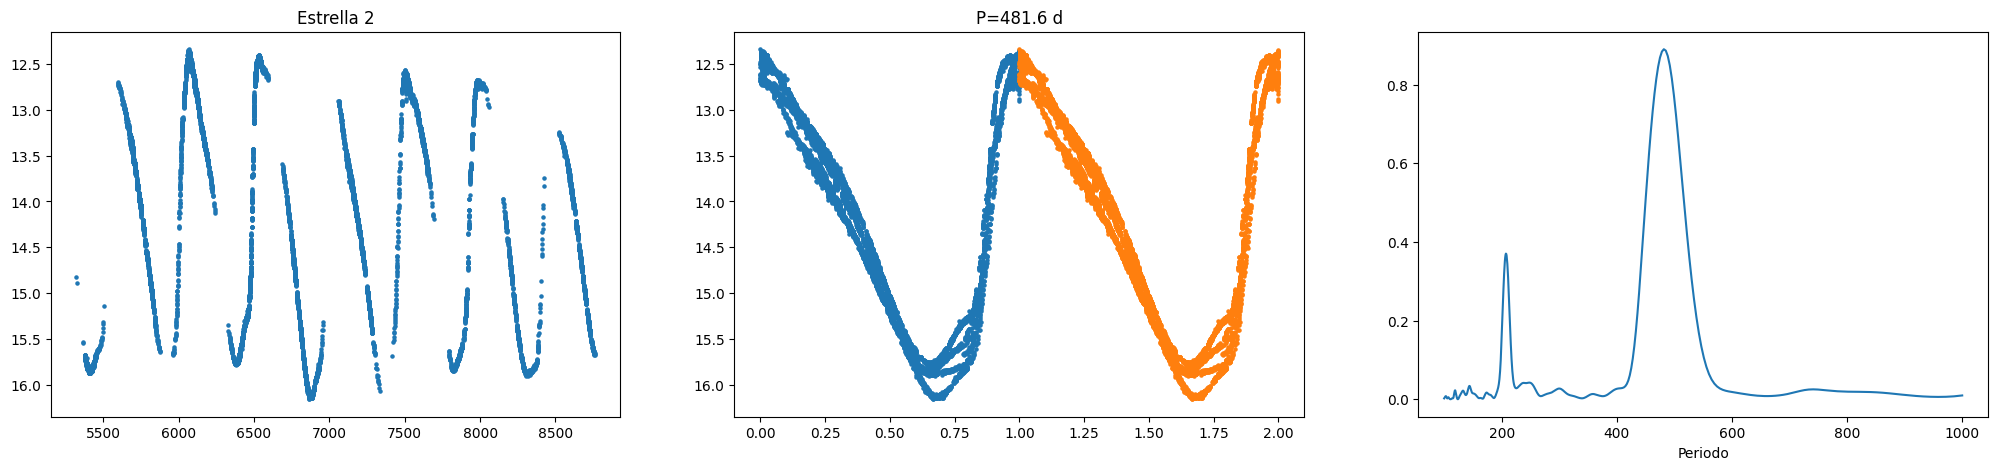

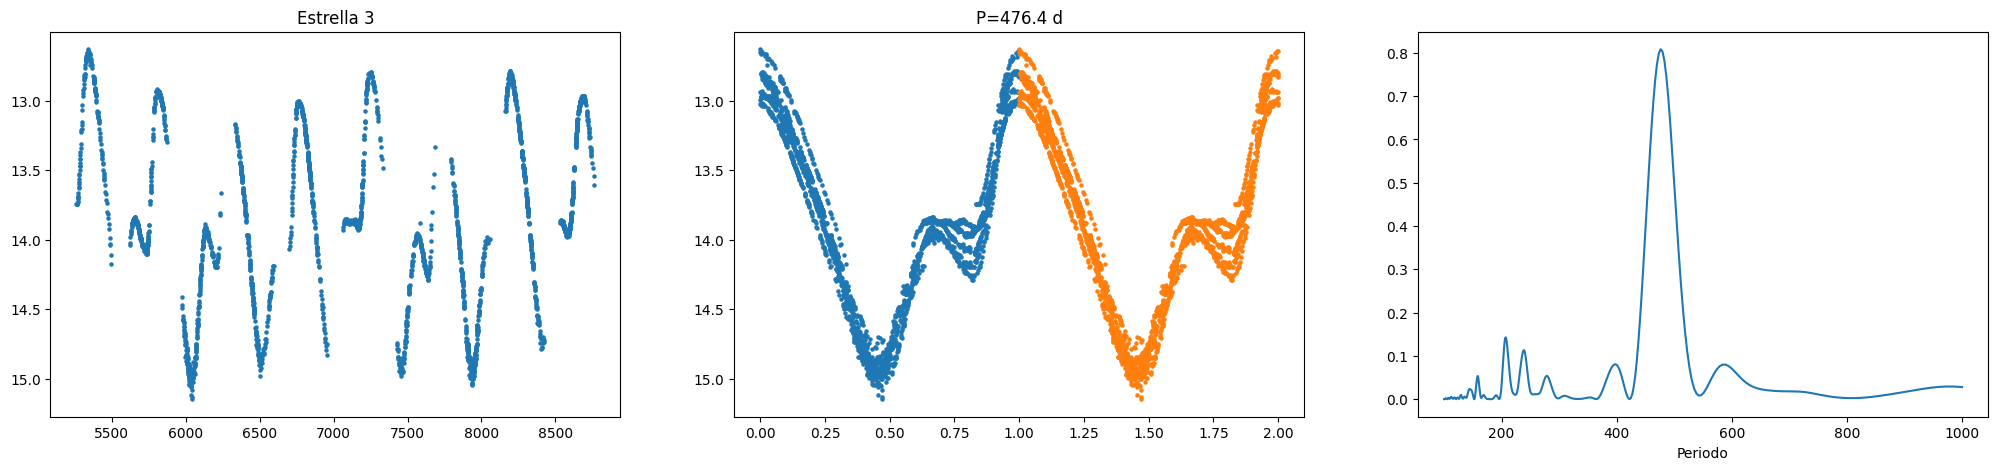

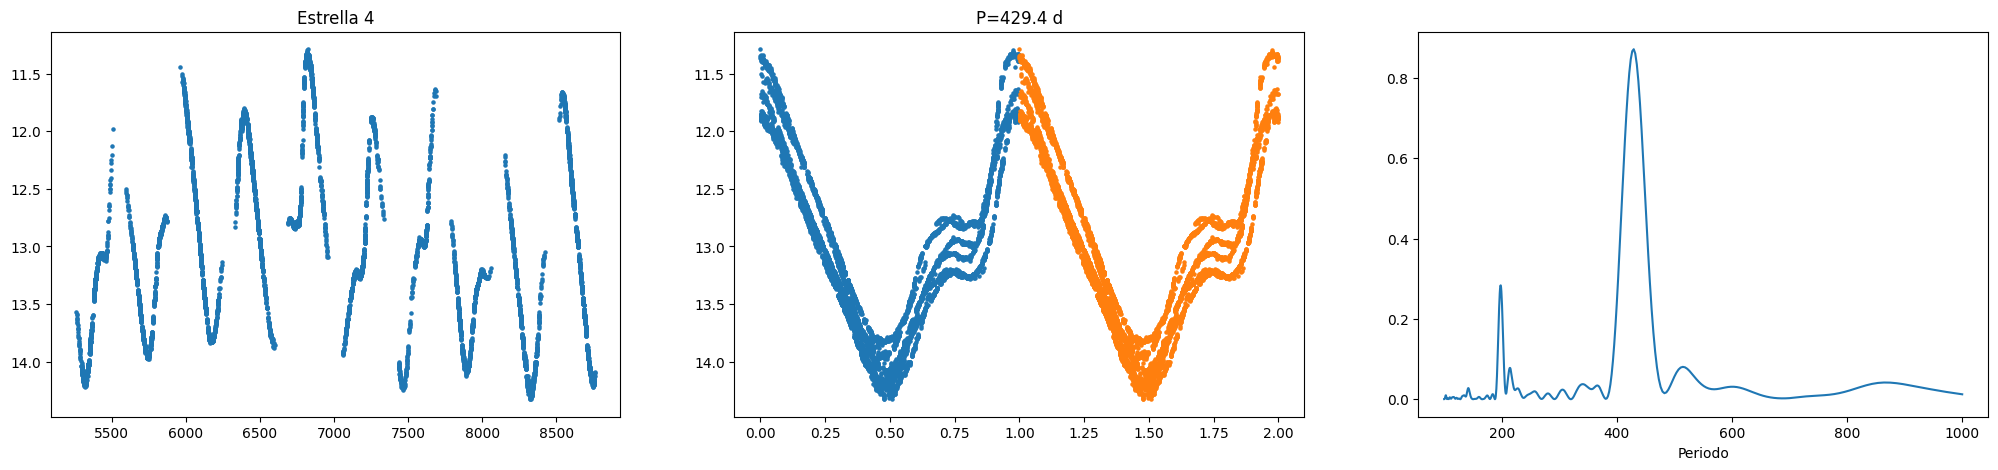

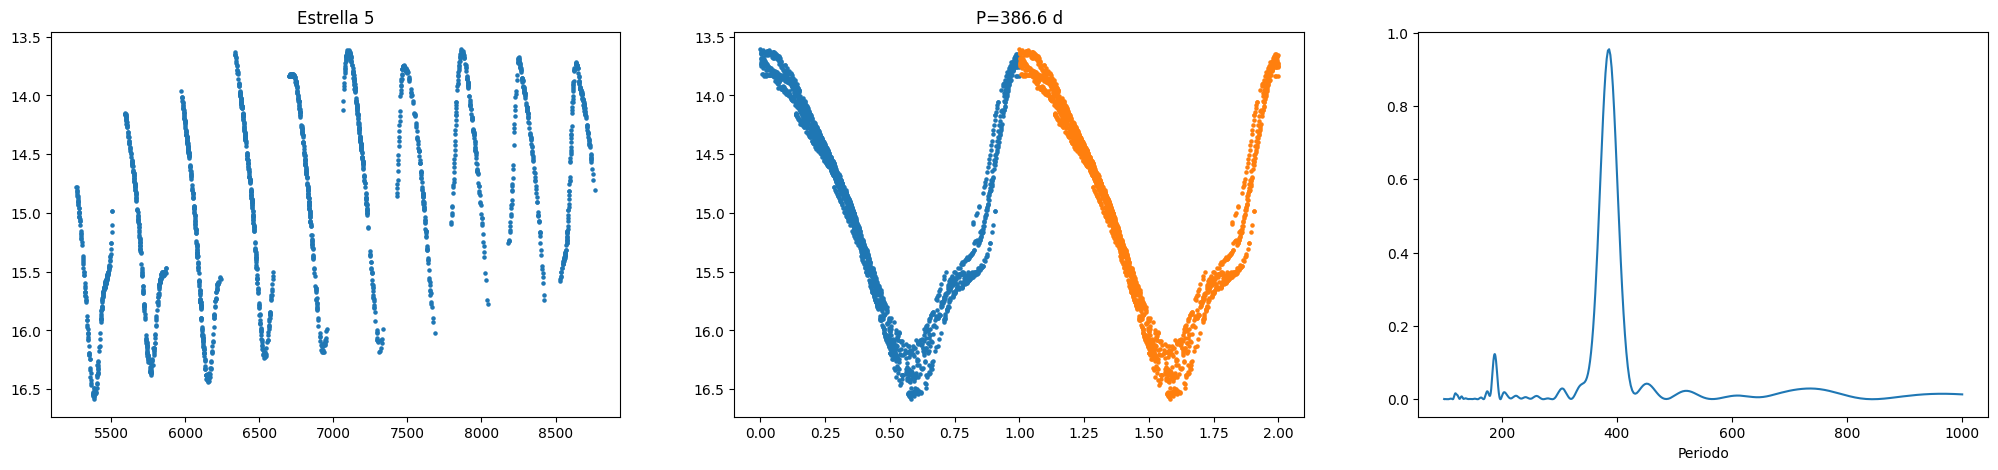

In [144]:
resultados=[]

for i, estrella in enumerate(estrellas):
    t, mag = limpiar(estrella["t"],estrella["mag"])
    freq, power, P0 = buscar_periodo(t,mag)
    P = refinar_periodo(t,mag,P0)
    fase = calcular_fase(t,mag,P0)

    resultados.append({"estrella":i+1,"P_LS":P0,"P_final":P})
    order=np.argsort(fase)
    
    fig,ax=plt.subplots(1,3,figsize=(25,5))

    ax[0].scatter(t,mag,s=5)
    ax[0].invert_yaxis()
    ax[0].set_title(f"Estrella {i+1}")


    ax[1].scatter(fase[order],mag[order],s=5)
    ax[1].scatter(fase[order]+1,mag[order],s=5)
    ax[1].invert_yaxis()
    ax[1].set_title(f"P={P0:.1f} d")


    ax[2].plot(1/freq,power)
    ax[2].set_xlabel("Periodo")
    plt.show()

In [145]:
pd.DataFrame(resultados)

,estrella,P_LS,P_final
0,1,579.741972,578.772503
1,2,481.641669,480.514080
2,3,476.381462,476.222137
3,4,429.357558,429.501156
4,5,386.584015,386.454723


El periodo que encontramos parece estar bien para cada estrella. También revisamos que la forma rara se da por un cambio entre los ciclos, no por cosas más extrañas. entonces, ahora vamos a empezar a utilizar fourier para refinar estos resultados, pero no necesariamente el periodo.

In [146]:
class FourierSeries:
    def __init__(self,n_terms=None,base_freq=None,custom_freqs=None):
        """Represents the b0 + Σₙ [ Aₙ cos(2πfₙt) + Bₙ sin(2πfₙt) ] series. 
        If initialized with only `n_terms`, the `base_freq` is assumed to be 1.0. 
        fₙ = n*base_freq, unless `custom_freqs` is provided, which is used to extract the fₙ.
        If both `custom_freqs` and `n_terms` are specified, the first n elements are used.
        If none are specified, the series will have one term by default.
        """
        self.fitted = False

        if custom_freqs is not None:
            if n_terms is None:
                n_terms = len(custom_freqs)
            self._freqs = np.array(custom_freqs[:n_terms])
        else:
            if n_terms is None:
                n_terms = 1
            if base_freq is None:
                base_freq = 1.0
            self._freqs = np.array([(i+1)*base_freq for i in range(n_terms)])
        self.n_terms = n_terms
        self._raw_coef = np.zeros(1+2*n_terms)
        self._param_names = ["base"] + list(tz.interleave((
            [f"A_{i+1}" for i in range(n_terms)],
            [f"B_{i+1}" for i in range(n_terms)]
        )))
    
    def __repr__(self):
        return f"<FourierSeries with {self.n_terms} terms>\nfitted: {self.fitted}\nparameters:\n" + self.parameters.to_string()
    
    def _design_matrix(self,ts):
        ts = np.array(ts)
        N = len(ts)
        const = np.ones(N)
        SIN = np.sin(2*np.pi*self._freqs[:,None]*ts[None,:])
        COS = np.cos(2*np.pi*self._freqs[:,None]*ts[None,:])
        return np.vstack([const] + list(tz.interleave([SIN,COS]))).T
        
    def __call__(self,t):
        scalar = np.isscalar(t)
        T = np.atleast_1d(t)
        X = self._design_matrix(T)
        return X @ self._raw_coef
    
    @property
    def parameters(self):
        return pd.Series(self._raw_coef,index=self._param_names)

    @property
    def A_n(self):
        return self._raw_coef[1::2]

    @property
    def B_n(self):
        return self._raw_coef[2::2]
        
        
    def fit(self,xdata,ydata,weights=None):
        """Performs OLS fit on the given data, which must be free of NaNs and infinite values.
        This instance is given the fitted parameters and the covariance matrix
        """
        X = self._design_matrix(xdata)
        self._raw_coef = np.linalg.pinv(X) @ ydata
        response = X @ self._raw_coef
        self.fitted = True
        return ydata - response

In [147]:
def amplitudes(self):
    # Los coeficientes van: base, A1, B1, A2, B2, ...
    An = self._raw_coef[1::2]  # índices 1, 3, 5, 7
    Bn = self._raw_coef[2::2]  # índices 2, 4, 6, 8
    return np.sqrt(An**2 + Bn**2)

def phases(self):
    An = self._raw_coef[1::2]
    Bn = self._raw_coef[2::2]
    return np.arctan2(Bn, An)

FourierSeries.amplitudes = property(amplitudes)
FourierSeries.phases     = property(phases)

Confirmamos que se trata de una mira con esta parábola, lo observado y lo calculado se empuezan a desviar a medida que pasan los ciclos.

In [148]:
def refinar_periodo_fourier(t,mag,P0,frac=0.03,N=400,n_terms=20):
    periodos=np.linspace(P0*(1-frac),P0*(1+frac),N)
    rms=[]
    for P in periodos:
        fase=((t-t.min())/P)%1
        order=np.argsort(fase)
        fs=FourierSeries(n_terms=n_terms,base_freq=1)
        res=fs.fit(fase[order],mag[order])
        rms.append(np.std(res))
    return periodos[np.argmin(rms)]

In [149]:
def OC_por_ciclo(t, mag, ciclo, P):
    ns, ocs = [], []
    
    # t0 = tiempo del máximo de magnitud (mínimo brillo) en ciclo 0
    m0 = ciclo == np.min(ciclo[ciclo >= 0])  
    if m0.sum() >= 5:
        t0 = t[m0][np.argmax(mag[m0])]
    else:
        t0 = t[np.argmax(mag)]  # fallback
    
    for c in np.unique(ciclo):
        m = ciclo == c
        if m.sum() < 30:
            continue
        tc, yc = t[m], mag[m]
        t_obs  = tc[np.argmax(yc)]
        t_calc = t0 + c * P
        ns.append(c)
        ocs.append(t_obs - t_calc)

    # Para estrella 5, después de calcular ns, ocs:
    coeffs = np.polyfit(ns, ocs, 1)   # ajuste lineal
    pendiente = coeffs[0]              # días por ciclo

    P_corregido = P + pendiente        # corrección directa
    print(f"Pendiente O-C: {pendiente:.2f} d/ciclo")
    print(f"P corregido:   {P_corregido:.2f} d")
    return np.array(ns), np.array(ocs)

In [150]:
def delta_fase_por_ciclo(fase_global, mag, ciclo, fs_global):
    """Desplazamiento Δφ que minimiza residuo de cada ciclo vs modelo global."""
    deltas = {}
    for c in np.unique(ciclo):
        m = ciclo == c
        if m.sum() < 30:
            continue
        fc, yc = fase_global[m], mag[m]
        def res(d):
            return np.sum((yc - fs_global((fc + d) % 1))**2)
        r = minimize_scalar(res, bounds=(-0.3, 0.3), method='bounded')
        deltas[c] = r.x
    return deltas

In [151]:
archivos = ["star1.csv","star2.csv","star3.csv","star4.csv","star5.csv"]
estrellas_raw = [pd.read_csv(f, sep=r"\s+", header=None) for f in archivos]

Pendiente O-C: 0.88 d/ciclo
P corregido:   580.31 d
Pendiente O-C: -5.54 d/ciclo
P corregido:   475.71 d
Pendiente O-C: -20.41 d/ciclo
P corregido:   456.15 d
Pendiente O-C: 0.87 d/ciclo
P corregido:   429.74 d
Pendiente O-C: -5.75 d/ciclo
P corregido:   380.57 d


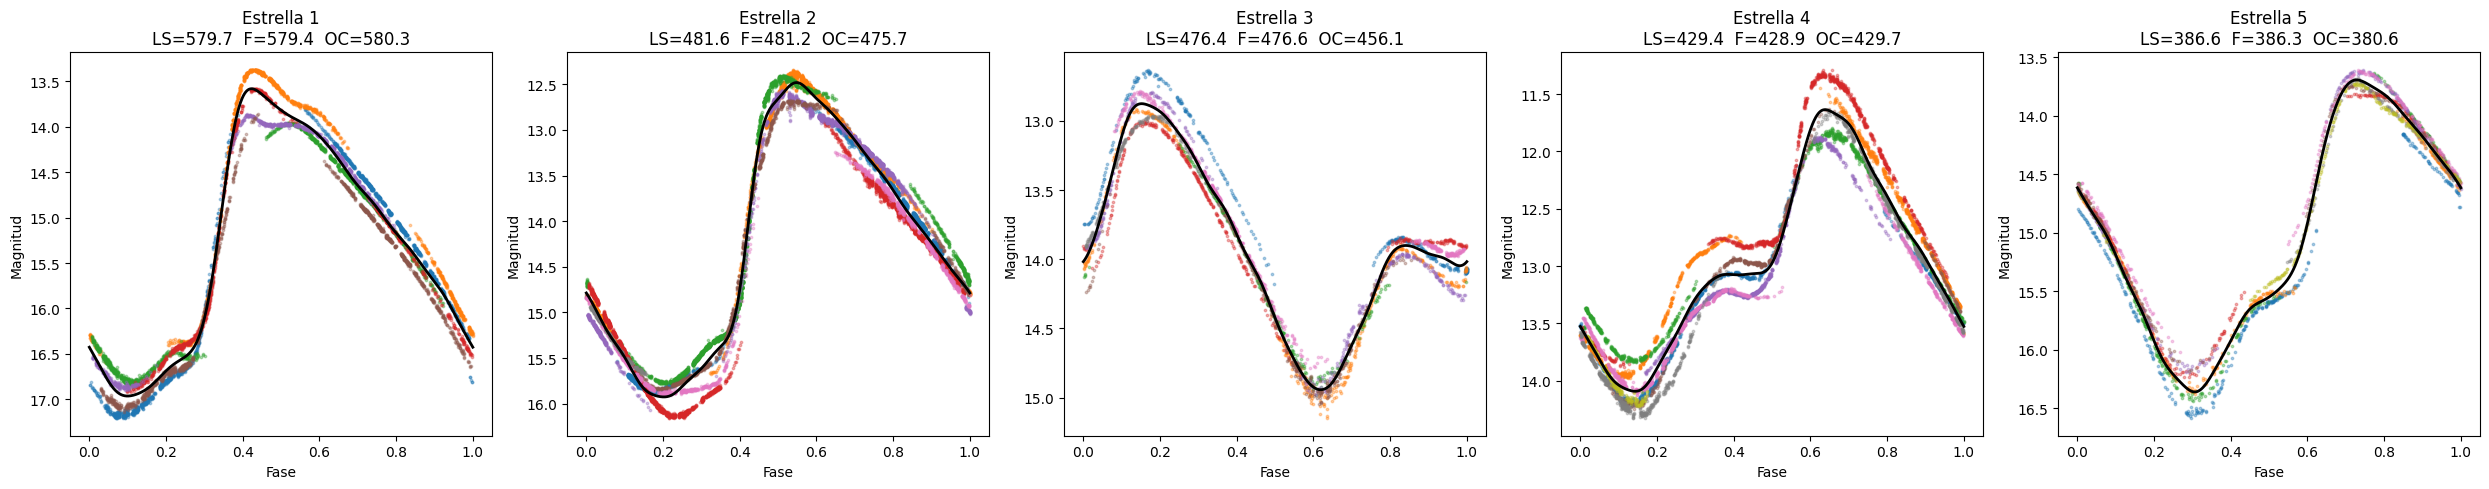

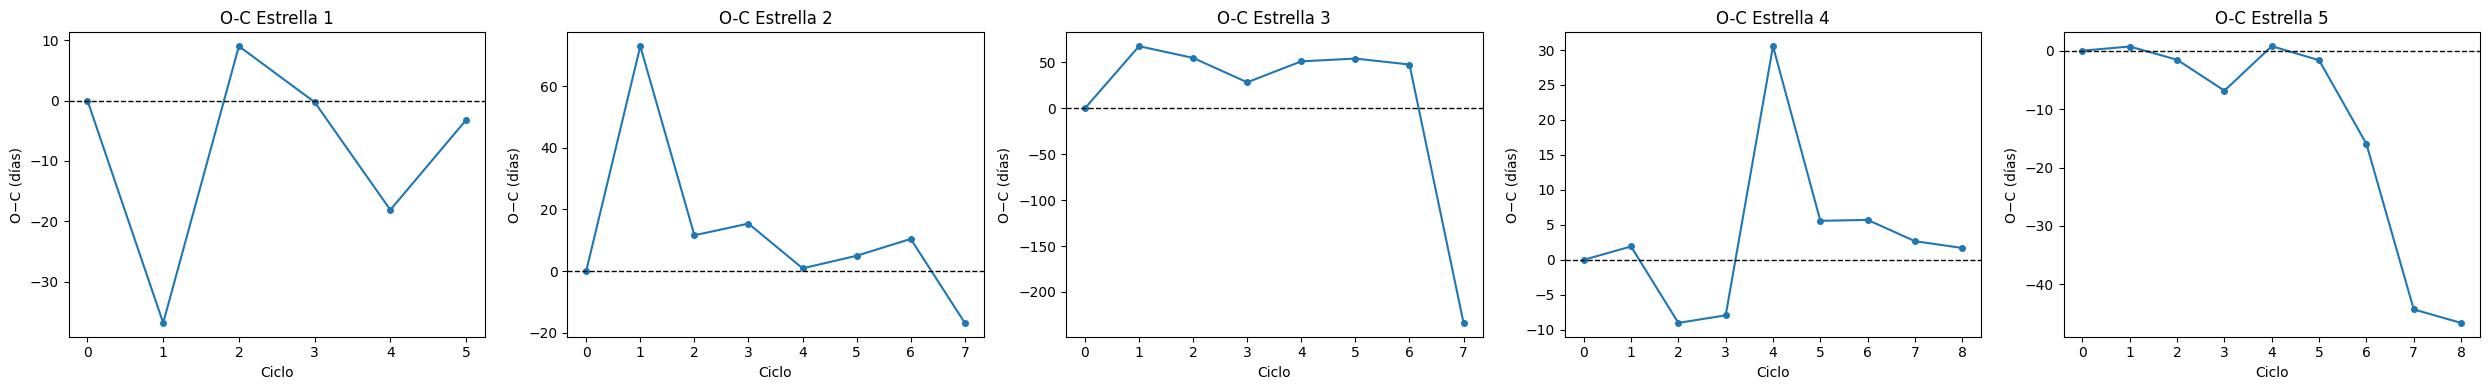

In [152]:
resultados = []
fig_fold, axes_fold = plt.subplots(1, 5, figsize=(25, 5))
fig_oc, axes_oc = plt.subplots(1, 5, figsize=(25, 4))
for i, df in enumerate(estrellas_raw):
    t, mag = limpiar(df[0], df[1])
    P0 = get_periodo(t, mag)
    P = refinar_periodo_fourier(t,mag,P0,frac=0.03,N=400,n_terms=20)
    ciclo = np.floor((t - t.min()) / P).astype(int)
    fase_global = ((t - t.min()) / P) % 1
    order = np.argsort(fase_global)
    fase_ord = fase_global[order]
    mag_ord = mag[order]

    fs = FourierSeries(n_terms=12,base_freq=1.0)
    res = fs.fit(fase_ord,mag_ord)
    rms = np.std(res)
    ns, ocs = OC_por_ciclo(t,mag,ciclo,P)
    pendiente = 0
    if len(ns) >= 4:
        pendiente = np.polyfit(ns,ocs,1)[0]
        P_oc = P + pendiente
    else:
        P_oc = P
    deltas = delta_fase_por_ciclo(fase_global,mag,ciclo,fs)
    A = fs.amplitudes
    phi = fs.phases
    if len(A) >= 2 and A[0] != 0:
        R21 = A[1] / A[0]
        phi21 = (phi[1] - 2 * phi[0])
    else:
        R21 = np.nan
        phi21 = np.nan

    resultados.append({"estrella": i + 1,"P_LS": round(P0, 2),"P_final": round(P, 2),
        "P_OC": round(P_oc, 2),"OC_pendiente": round(pendiente,4),"A1": round(A[0],4) if len(A) else np.nan,
        "R21": round(R21,4),"phi21": round(phi21,4),"RMS": round(rms,4),"OC_std": round(np.std(ocs),2) if len(ocs) else np.nan})
    ax = axes_fold[i]
    for c in np.unique(ciclo):
        m = ciclo == c
        if (m.sum() < 30 or c not in deltas):
            continue
        fase_c = (fase_global[m] + deltas[c]) % 1
        ax.scatter(fase_c,mag[m],s=3,alpha=0.35)
    ff = np.linspace(0,1,1000)
    ax.plot(ff,fs(ff),lw=2,color="black")
    ax.invert_yaxis()
    ax.set_title(f"Estrella {i+1}\n"f"LS={P0:.1f}  "f"F={P:.1f}  "f"OC={P_oc:.1f}")
    ax.set_xlabel("Fase")
    ax.set_ylabel("Magnitud")
    ax2 = axes_oc[i]
    if len(ns):
        ax2.plot(ns,ocs,"o-",ms=4)
    ax2.axhline(0,color="k",lw=1,ls="--")
    ax2.set_title(f"O-C Estrella {i+1}")
    ax2.set_xlabel("Ciclo")
    ax2.set_ylabel("O−C (días)")
fig_fold.tight_layout()
fig_fold.savefig("curvas_plegadas.png",dpi=150)
fig_oc.tight_layout()
fig_oc.savefig("OC_diagrams.png",dpi=150)

plt.show()

Por alguna razón las estrellas no están en los archivos descargados, pero yo tengo los nombres y sé que las estrellas existen

Pendiente O-C: 0.88 d/ciclo
P corregido:   580.31 d
Pendiente O-C: -5.54 d/ciclo
P corregido:   475.71 d
Pendiente O-C: -20.41 d/ciclo
P corregido:   456.15 d
Pendiente O-C: 0.87 d/ciclo
P corregido:   429.74 d
Pendiente O-C: -5.75 d/ciclo
P corregido:   380.57 d


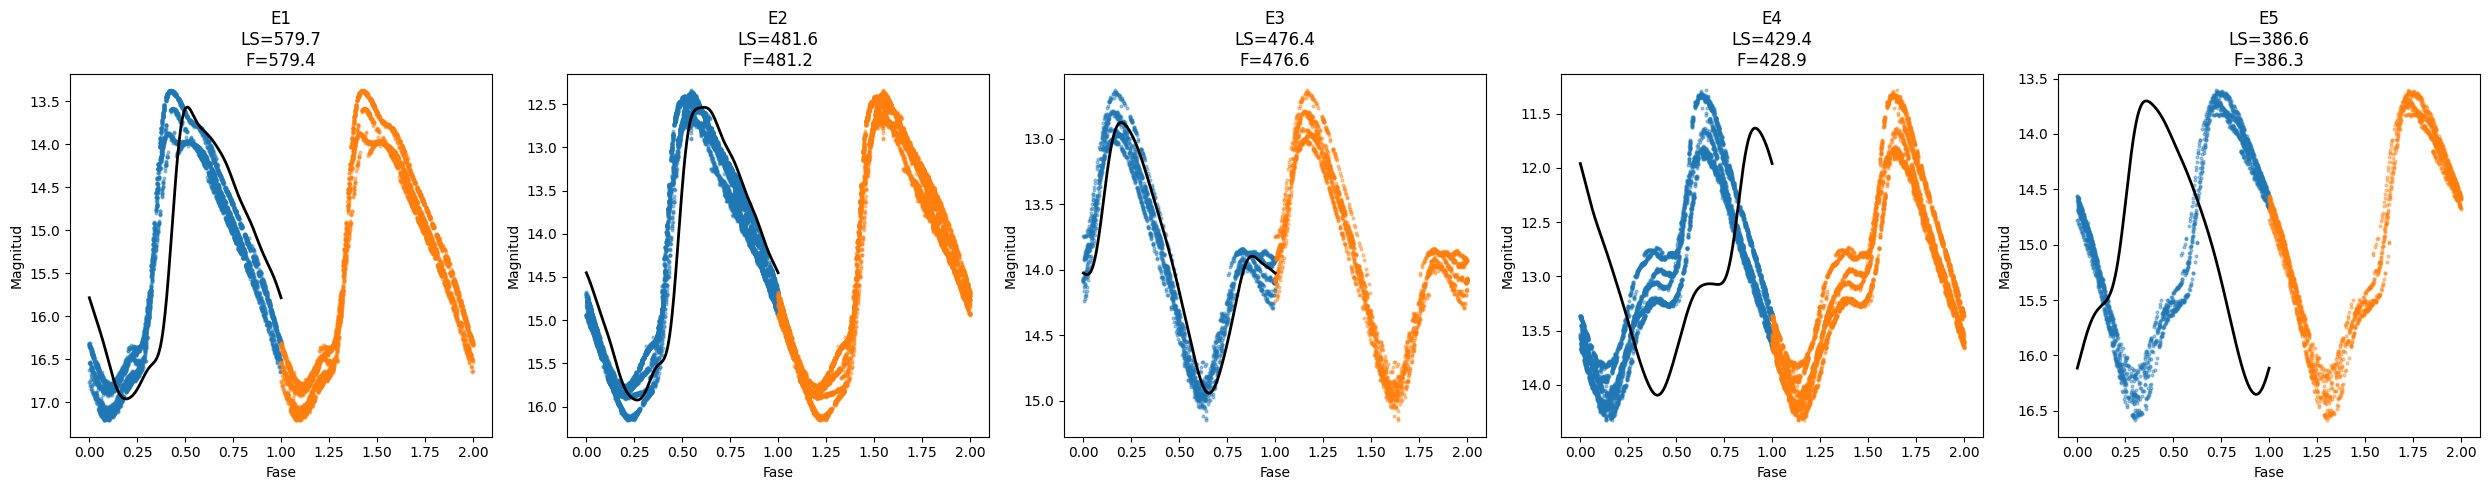

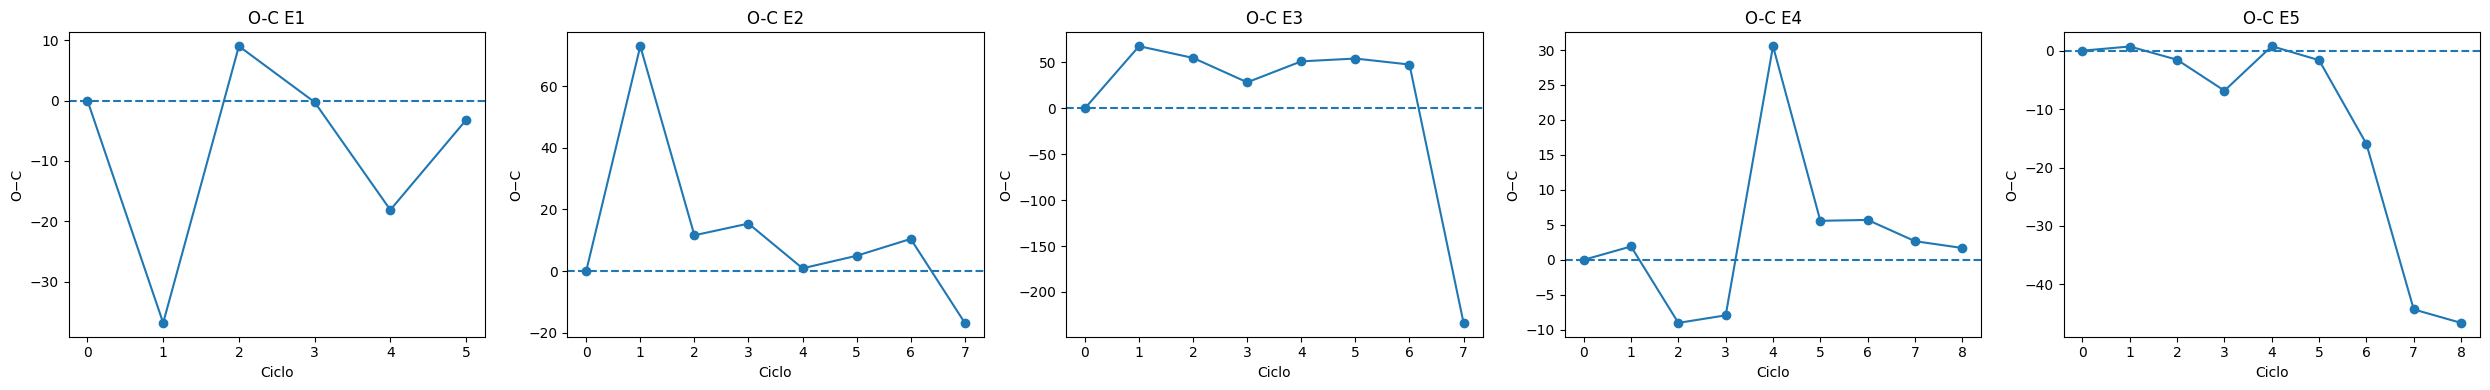

 estrella   P_LS  P_fold  P_fourier   P_OC  dP_fold  dP_fourier   dP_OC     A1    R21   phi21    RMS  OC_pendiente
        1 579.74  578.77     579.44 580.31   -0.969      -0.305   0.876 1.5281 0.3016 -3.0288 0.1553        0.8762
        2 481.64  480.51     481.24 475.71   -1.128      -0.398  -5.536 1.5733 0.2977 -3.1349 0.1407       -5.5356
        3 476.38  476.22     476.56 456.15   -0.159       0.179 -20.411 0.7973 0.3357  6.4333 0.1003      -20.4111
        4 429.36  429.50     428.87 429.74    0.144      -0.484   0.867 0.9964 0.1926  0.5827 0.1710        0.8665
        5 386.58  386.45     386.32 380.57   -0.129      -0.262  -5.750 1.2139 0.0758 -3.2498 0.0962       -5.7500


In [153]:
def refinar_periodo_fourier_tiempo(t,mag,P0,frac=0.03,N=120,n_terms=8):
    periodos = np.linspace(P0*(1-frac),P0*(1+frac),N)
    rss = []
    for P in periodos:
        freqs = np.arange(1,n_terms+1) / P
        fs = FourierSeries(custom_freqs=freqs)
        res = fs.fit(t,mag)
        rss.append(np.sum(res**2))
    return float(periodos[np.argmin(rss)])

resultados = []
fig_fold, axes_fold = plt.subplots(1,5,figsize=(25,5))
fig_oc, axes_oc = plt.subplots(1,5,figsize=(25,4))
for i, df in enumerate(estrellas_raw):
    t, mag = limpiar(df[0],df[1])
    P0 = get_periodo(t,mag)
    P = refinar_periodo_fourier_tiempo(t,mag,P0,frac=0.03,N=400,n_terms=20)
    ciclo = np.floor((t-t.min())/P).astype(int)
    fase = ((t-t.min())/P) % 1
    order = np.argsort(fase)
    fase_ord = fase[order]
    mag_ord = mag[order]
    freqs = np.arange(1,9) / P
    fs = FourierSeries(custom_freqs=freqs)
    res = fs.fit(t,mag)
    rms = np.std(res)
    ns, ocs = OC_por_ciclo(t,mag,ciclo,P)
    pendiente = 0
    if len(ns) >= 4:
        pendiente = np.polyfit(ns,ocs,1)[0]
        P_oc = P + pendiente
    else:
        P_oc = P
    A = fs.amplitudes
    phi = fs.phases
    if len(A)>=2 and A[0]!=0:
        R21 = A[1]/A[0]
        phi21 = (phi[1] - 2*phi[0])
    else:
        R21 = np.nan
        phi21 = np.nan
        
    P_fold = refinar_periodo(t,mag,P0)
    resultados.append({"estrella": i+1,"P_LS":round(P0,2),"P_fold":round(refinar_periodo(t,mag,P0),2),
    "P_fourier":round(P,2),"P_OC":round(P_oc,2),"dP_fold":round(refinar_periodo(t,mag,P0) - P0, 3),"dP_fourier":round(P - P0,3),
    "dP_OC":round(P_oc - P,3),"A1":round(A[0],4),"R21":round(R21,4),"phi21":round(phi21,4),
    "RMS":round(rms,4),"OC_pendiente":round(pendiente,4)})
    ax = axes_fold[i]
    ax.scatter(fase_ord,mag_ord,s=4,alpha=0.4)
    ax.scatter(fase_ord+1,mag_ord,s=4,alpha=0.4)
    ff = np.linspace(0,1,1000)
    tt = ff*P
    ax.plot(ff,fs(tt),lw=2,color="black")
    ax.invert_yaxis()
    ax.set_title(f"E{i+1}\n"f"LS={P0:.1f}\n"f"F={P:.1f}")
    ax.set_xlabel("Fase")
    ax.set_ylabel("Magnitud")
    ax2 = axes_oc[i]
    if len(ns):
        ax2.plot(ns,ocs,"o-")
    ax2.axhline(0,ls="--")
    ax2.set_title(f"O-C E{i+1}")
    ax2.set_xlabel("Ciclo")
    ax2.set_ylabel("O−C")

fig_fold.tight_layout()
fig_oc.tight_layout()
plt.show()
tabla = pd.DataFrame(resultados)
print(tabla.to_string(index=False))